# 自适应推理性能分布诊断

读取 `infer/_output` 中已落盘的 `adaptive_tracker` 指标。可修改下方参数，查看任一指标的样本分布，并从该指标最佳或最差的一组样本中随机展示一张诊断图。


## 1. 参数

`METRIC_PATH` 使用 `<分组>.<字段>` 形式，例如 `trajectory.mae_m`、`trajectory.coverage`、`compute.blocks_evaluated`、`timing.end_to_end_total_s` 或 `tracker.recapture_start_count`。`RANDOM_SEED=None` 表示每次执行都会随机选图。


In [18]:
from pathlib import Path

# 推理输出与待分析指标
OUTPUT_DIR = Path(
    "/mnt/host-model/weixc/code/LineTracker/method/SimpleCNN/"
    "infer/_output/F300-N10k-S42--v2-n-best-s42000"
)
TIME_STRIDE = 5
METRIC_PATH = "trajectory.mae_m"
NUM_BINS = 20
OUTLIER_IQR_MULTIPLIER = 3.0  # 非 [0, 1] 指标的自动展示范围：Q1/Q3 向外扩展该倍数 IQR

# 选择并展示指标最优或最差的 N% 样本；None 时根据指标名称自动判断方向。
COHORT = "worst"  # "best" 或 "worst"
COHORT_FRACTION = 0.05
HIGHER_IS_BETTER = None  # True / False 可手工覆盖自动判断
RANDOM_SEED = None       # None：每次运行随机取一张；整数：复现实验

assert TIME_STRIDE >= 1
assert NUM_BINS >= 3  # 左右离群 bin 外至少保留一个主体区间。
assert OUTLIER_IQR_MULTIPLIER >= 0.0
assert COHORT in {"best", "worst"}
assert 0.0 < COHORT_FRACTION <= 1.0
assert HIGHER_IS_BETTER in {None, True, False}


## 2. 加载 v4/v5 兼容指标

直接导入 `summary.py` 的公共方法：它会将旧版 v4 的 `compute` 耗时与新版 v5 的 `timing` 耗时归一化。


In [19]:
import sys

import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

# 显式选用系统已安装的中文字体，避免 IPython 渲染中文标题时回退到 DejaVu Sans。
CJK_FONT_CANDIDATES = ("WenQuanYi Micro Hei", "Noto Sans CJK SC", "Source Han Sans SC", "SimHei")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
CJK_FONT = next((name for name in CJK_FONT_CANDIDATES if name in available_fonts), None)
assert CJK_FONT is not None, "未找到可用中文字体；请安装 Noto Sans CJK 或文泉驿微米黑。"
plt.rcParams.update({"font.family": [CJK_FONT, "DejaVu Sans"], "axes.unicode_minus": False})
print(f"绘图中文字体：{CJK_FONT}")

SUMMARY_DIR = OUTPUT_DIR.parents[1] / "adaptive_tracker"
if str(SUMMARY_DIR) not in sys.path:
    sys.path.insert(0, str(SUMMARY_DIR))

from summary import build_summary, load_samples

summary_path, summary_payload = build_summary(OUTPUT_DIR, time_stride=TIME_STRIDE)
samples = load_samples(OUTPUT_DIR, time_stride=TIME_STRIDE)
print(f"已加载 {len(samples)} 个样本；汇总文件：{summary_path.name}")
print(f"输入 metrics schema：{summary_payload['input']['metrics_schema_versions']}")


绘图中文字体：WenQuanYi Micro Hei


已加载 2105 个样本；汇总文件：adaptive_tracker_stride5_samples0000-2104.json
输入 metrics schema：{'v4': 1916, 'v5': 189}


## 3. 选择指标并准备样本表


In [20]:
METRIC_LABELS = {
    "trajectory.coverage": "轨迹覆盖率",
    "trajectory.mae_m": "平均绝对误差（米）",
    "trajectory.rmse_m": "均方根误差（米）",
    "trajectory.abs_error_p95_m": "绝对误差 P95（米）",
    "trajectory.hit_coverage": "目标命中区间覆盖率",
    "trajectory.hit_mae_m": "目标命中区间 MAE（米）",
    "trajectory.unreliable_coverage": "不可靠外推覆盖率",
    "trajectory.jump_count": "轨迹跳变次数",
    "compute.blocks_evaluated": "评估距离块数",
    "compute.forward_calls": "模型前向次数",
    "compute.logical_steps": "逻辑推理步数",
    "timing.end_to_end_total_s": "样本端到端推理时间（秒）",
    "timing.end_to_end_mean_ms": "单逻辑步平均耗时（毫秒）",
    "timing.end_to_end_p95_ms": "单逻辑步耗时 P95（毫秒）",
    "tracker.recapture_start_count": "重捕获启动次数",
    "tracker.capture_scan_count": "全局捕获扫描次数",
    "tracker.local_scan_count": "局部跟踪扫描次数",
}


def metric_value(sample: dict, metric_path: str) -> float:
    section, key = metric_path.split(".", maxsplit=1)
    assert section in {"trajectory", "compute", "timing", "tracker"}, f"未知指标分组：{section}"
    value = sample[section].get(key)
    assert value is not None and np.isfinite(float(value)), f"{sample['source_id']} 缺少有限指标 {metric_path}"
    return float(value)


def infer_higher_is_better(metric_path: str) -> bool:
    lower_is_better_terms = (
        "mae", "rmse", "error", "jump", "unreliable", "time", "ms",
        "blocks", "calls", "steps", "recapture", "scan",
    )
    return not any(term in metric_path.lower() for term in lower_is_better_terms)


METRIC_PATH = "trajectory.mae_m"

metric_frame = pd.DataFrame(
    {
        "source_id": [sample["source_id"] for sample in samples],
        "source_index": [sample["source_index"] for sample in samples],
        "value": [metric_value(sample, METRIC_PATH) for sample in samples],
    }
).sort_values("source_index", ignore_index=True)

metric_label = METRIC_LABELS.get(METRIC_PATH, METRIC_PATH)
higher_is_better = infer_higher_is_better(METRIC_PATH) if HIGHER_IS_BETTER is None else HIGHER_IS_BETTER
display(metric_frame["value"].describe(percentiles=[0.05, 0.5, 0.95]).to_frame(name=metric_label))
print(f"排序方向：{'数值越大越好' if higher_is_better else '数值越小越好'}")


,平均绝对误差（米）
count,2105.000000
mean,697.704670
std,8436.501157
min,8.361097
5%,12.005564
50%,20.228685
95%,81.333385
max,276136.764432


排序方向：数值越小越好


## 4. 指标分布

柱高表示样本落在对应数值区间内的比例，而非绝对样本数。主体区间使用线性等宽分箱；超出自动展示范围的样本分别聚合到 `<下界` 与 `>上界` 两个边界 bin，避免少数离群值压缩主体分布。


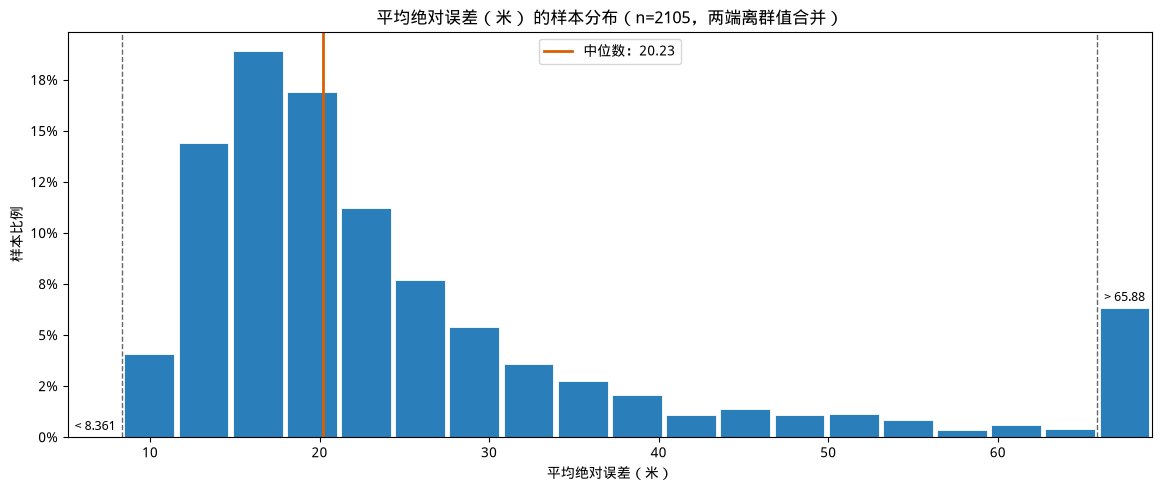

主体展示范围：[8.3611, 65.8782]；< 下界：0.00%，> 上界：6.32%
min=8.3611，median=20.2287，p95=81.3334，max=276137


In [21]:
values = metric_frame["value"].to_numpy(dtype=np.float64)
value_min, value_max = float(values.min()), float(values.max())

# 0–1 有界指标完整显示；其他指标以 IQR 自动确定主体显示范围。
if 0.0 <= value_min and value_max <= 1.0:
    display_lower, display_upper = 0.0, 1.0
else:
    q1, q3 = np.percentile(values, [25, 75])
    iqr = float(q3 - q1)
    if iqr > 0.0:
        display_lower = max(value_min, float(q1 - OUTLIER_IQR_MULTIPLIER * iqr))
        display_upper = min(value_max, float(q3 + OUTLIER_IQR_MULTIPLIER * iqr))
    else:
        display_lower, display_upper = value_min, value_max

# 常数指标也保留可见的横轴宽度；主体区间两端以 < / > bin 聚合离群值。
if display_upper <= display_lower:
    padding = max(abs(display_lower) * 0.05, 1.0)
    display_lower, display_upper = display_lower - padding, display_upper + padding

inner_bin_count = NUM_BINS - 2
inner_edges = np.linspace(display_lower, display_upper, inner_bin_count + 1)
left_count = int(np.count_nonzero(values < display_lower))
right_count = int(np.count_nonzero(values > display_upper))
inner_counts, _ = np.histogram(values[(values >= display_lower) & (values <= display_upper)], bins=inner_edges)
counts = np.concatenate(([left_count], inner_counts, [right_count]))
proportions = counts / counts.sum()

bin_width = float(inner_edges[1] - inner_edges[0])
centers = np.concatenate((
    [display_lower - bin_width / 2.0],
    (inner_edges[:-1] + inner_edges[1:]) / 2.0,
    [display_upper + bin_width / 2.0],
))

fig, ax = plt.subplots(figsize=(11.5, 4.8), constrained_layout=True)
ax.bar(centers, proportions, width=bin_width * 0.92, color="#2a7fbb", edgecolor="white", linewidth=0.6)
ax.axvline(np.median(values), color="#d95f02", linewidth=2, label=f"中位数：{np.median(values):.4g}")
ax.axvline(display_lower, color="#666666", linestyle="--", linewidth=1)
ax.axvline(display_upper, color="#666666", linestyle="--", linewidth=1)
ax.annotate(f"< {display_lower:.4g}", (centers[0], proportions[0]), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=9)
ax.annotate(f"> {display_upper:.4g}", (centers[-1], proportions[-1]), xytext=(0, 5), textcoords="offset points", ha="center", fontsize=9)
ax.set_xlim(display_lower - bin_width, display_upper + bin_width)
ax.set_title(f"{metric_label} 的样本分布（n={len(values)}，两端离群值合并）")
ax.set_xlabel(metric_label)
ax.set_ylabel("样本比例")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.legend()
plt.show()

print(
    f"主体展示范围：[{display_lower:.6g}, {display_upper:.6g}]；"
    f"< 下界：{left_count / len(values):.2%}，> 上界：{right_count / len(values):.2%}"
)
print(
    f"min={value_min:.6g}，median={np.median(values):.6g}，"
    f"p95={np.percentile(values, 95):.6g}，max={value_max:.6g}"
)


## 5. 最佳/最差分位样本的随机诊断图

先按指标方向选出目标集合，再从其中随机抽取一张 `visualize.png`。修改 `RANDOM_SEED` 可固定抽样结果。


trajectory.mae_m 的 worst 5.0%：共 106 个样本，随机选中 dataset1_synthetic_1460，指标值=85.8267


,source_id,source_index,平均绝对误差（米）
0,dataset1_synthetic_1361,1361,276136.764432
1,dataset1_synthetic_1864,1864,156372.213670
2,dataset1_synthetic_1703,1703,140964.662262
3,dataset1_synthetic_0031,31,74356.181409
4,dataset1_synthetic_0286,286,62819.595252
5,dataset1_synthetic_1165,1165,55463.151720
6,dataset1_synthetic_1657,1657,53787.582671
7,dataset1_synthetic_1319,1319,44709.338726
8,dataset1_synthetic_0772,772,35173.397250
9,dataset1_synthetic_1262,1262,34561.018554


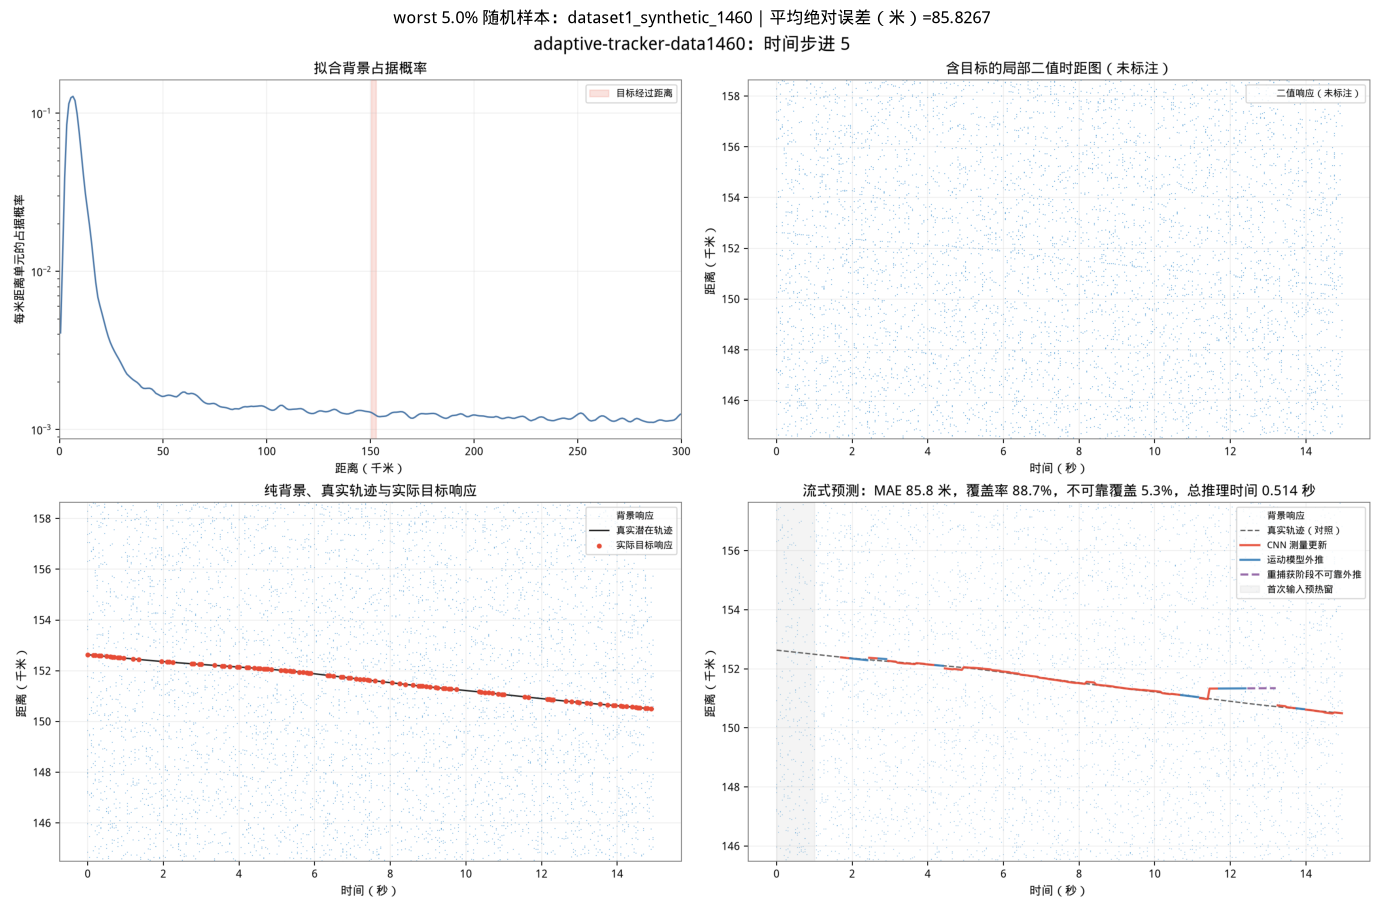

In [22]:
cohort_size = max(1, int(np.ceil(len(metric_frame) * COHORT_FRACTION)))
ascending = higher_is_better if COHORT == "worst" else not higher_is_better
cohort = metric_frame.sort_values("value", ascending=ascending, ignore_index=True).head(cohort_size)
selected = cohort.sample(n=1, random_state=RANDOM_SEED).iloc[0]

print(
    f"{METRIC_PATH} 的 {COHORT} {COHORT_FRACTION:.1%}："
    f"共 {cohort_size} 个样本，随机选中 {selected.source_id}，"
    f"指标值={selected.value:.6g}"
)
display(cohort.head(10).rename(columns={"value": metric_label}))

image_path = (
    OUTPUT_DIR / "samples" / selected.source_id / f"adaptive_tracker_stride{TIME_STRIDE}" / "visualize.png"
)
assert image_path.is_file(), f"未找到诊断图：{image_path}"
with Image.open(image_path) as image:
    figure, axis = plt.subplots(figsize=(16, 9), constrained_layout=True)
    axis.imshow(image)
    axis.set_title(f"{COHORT} {COHORT_FRACTION:.1%} 随机样本：{selected.source_id}｜{metric_label}={selected.value:.6g}")
    axis.axis("off")
    plt.show()
